# NoteBook说明
该Notebook文件主要功能为为分割模型计算MASK矩阵。采用卒中DWI金标准的影像分割结果，迁移至平扫CT中产生像素级分割MASK矩阵。

检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: False
可用GPU数:  0


2026-02-25 14:35:20.585512: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 14:35:20.648576: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-02-25 14:35:20.648614: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist


读取文件路径

In [8]:
#获取图片文件路径
import tqdm,os
ImageDirList=[]
FileAllPath=['/root/StrokeDataset/Ischemia/PNG']    #总文件路径
for fileallpath in tqdm.tqdm(FileAllPath):
    FilePath=os.listdir(fileallpath)    #读取总文件夹下文件
    for filepath in FilePath:
        Filepath=fileallpath+'/'+str(filepath)
        ImageDirList.append(Filepath)

100%|██████████| 1/1 [00:00<00:00, 883.57it/s]


In [9]:
#移除checkPoint文件
ImageDirList=[path for path in ImageDirList if ".ipynb_checkpoints" not in path]

In [10]:
#读取Overlay路径
OverlayDirList=[]
OverlayPath=['/root/StrokeDataset/Ischemia/OVERLAY']    #总文件路径
for fileallpath in tqdm.tqdm(OverlayPath):
    FilePath=os.listdir(fileallpath)    #读取总文件夹下文件
    for filepath in FilePath:
        Filepath=fileallpath+'/'+str(filepath)
        OverlayDirList.append(Filepath)

100%|██████████| 1/1 [00:00<00:00, 939.58it/s]


In [11]:
#移除checkPoint文件
OverlayDirList=[path for path in OverlayDirList if ".ipynb_checkpoints" not in path]

In [12]:
int(ImageDirList[0].split('/')[-1].split('.')[0])

10003

In [13]:
#检测是否存在配对错误
for png,overlay in zip(ImageDirList,OverlayDirList):
    png_name=int(png.split('/')[-1].split('.')[0])
    overlay_name=int(overlay.split('/')[-1].split('.')[0])
    if png_name!=overlay_name:
        print(png_name,onrtlay_name)        

In [14]:
#计算MASK矩阵
import cv2
import numpy as np
import gc
def ComputerMASK(png_path,overlay_path):
    png_image=cv2.imread(png_path)
    png_image=cv2.resize(png_image,dsize=(512,512))
    overlay_image=cv2.imread(overlay_path)
    overlay_image=cv2.resize(overlay_image,dsize=(512,512))
    MASK=overlay_image-png_image
    MASK[MASK>0]=1
    MASK[MASK<=0]=0
    MASK=MASK[..., 0:1]
    del png_image,overlay_image
    gc.collect()
    return MASK

In [15]:
MASK=ComputerMASK(png_path='/root/StrokeDataset/Ischemia/PNG/10003.png',
                  overlay_path='/root/StrokeDataset/Ischemia/OVERLAY/10003.png')

In [16]:
import matplotlib.pyplot as plt
def DisplayImage(image):
    plt.figure()
    plt.title('Image')
    plt.imshow(image)
    plt.show()

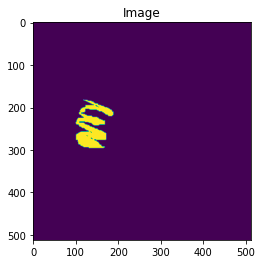

In [17]:
DisplayImage(image=MASK)

In [18]:
from collections import Counter
Counter(MASK.flatten())

Counter({0: 257183, 1: 4961})

In [20]:
#批量处理
import tqdm
MASK_Path=[]
Dir=zip(ImageDirList,OverlayDirList)
for png,overlay in tqdm.tqdm(Dir):
    MASK=ComputerMASK(png_path=png,overlay_path=overlay)
    filepath=png[:29]
    name=png.split('/')[-1].split('.')[0]
    MASK_path=filepath+'MASK/'+name+'.npy'
    np.save(MASK_path,MASK)
    MASK_Path.append(MASK_path)
    del MASK,filepath,name,MASK_path
    gc.collect()

1130it [13:58,  1.35it/s]


In [21]:
for png,mask in zip(ImageDirList,MASK_Path):
    png_name=int(png.split('/')[-1].split('.')[0])
    overlay_name=int(mask.split('/')[-1].split('.')[0])
    if png_name!=overlay_name:
        print(png_name,onrtlay_name)  

In [22]:
from pandas import DataFrame
MASKPath=DataFrame()
MASKPath['PNG']=ImageDirList
MASKPath['MASK']=MASK_Path

In [24]:
MASKPath.to_csv('/root/StrokeDataset/Ischemia/ImageWithMASKPath.csv',encoding='utf-8')